# Week 2 - Commit 1
## Feature Engineering: Tenure & Monthly Charges Features

### Objective
To create new features from customer tenure and monthly charges that can improve churn prediction performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [4]:
df['Tenure_Group'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=[
        'New Customer',
        'Regular Customer',
        'Loyal Customer',
        'Long-Term Customer'
    ]
)

df[['tenure', 'Tenure_Group']].head()

,tenure,Tenure_Group
0,1,New Customer
1,34,Loyal Customer
2,2,New Customer
3,45,Loyal Customer
4,2,New Customer


In [5]:
df['MonthlyCharge_Category'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0, 35, 70, 120],
    labels=['Low', 'Medium', 'High']
)

df[['MonthlyCharges', 'MonthlyCharge_Category']].head()

,MonthlyCharges,MonthlyCharge_Category
0,29.85,Low
1,56.95,Medium
2,53.85,Medium
3,42.30,Medium
4,70.70,High


In [6]:
df['Tenure_Group'].value_counts()

Tenure_Group
Long-Term Customer    2239
New Customer          2175
Loyal Customer        1594
Regular Customer      1024
Name: count, dtype: int64

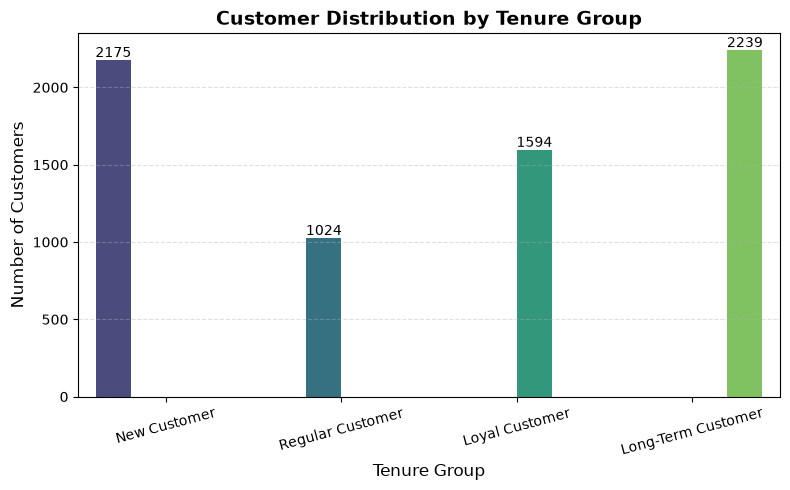

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import os



plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='Tenure_Group',
    data=df,
    hue='Tenure_Group',
    palette='viridis',
    legend=False
)

plt.title('Customer Distribution by Tenure Group',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Tenure Group', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Add values on bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()



plt.show()



In [9]:
df['MonthlyCharge_Category'].value_counts()

MonthlyCharge_Category
High      3583
Low       1735
Medium    1725
Name: count, dtype: int64

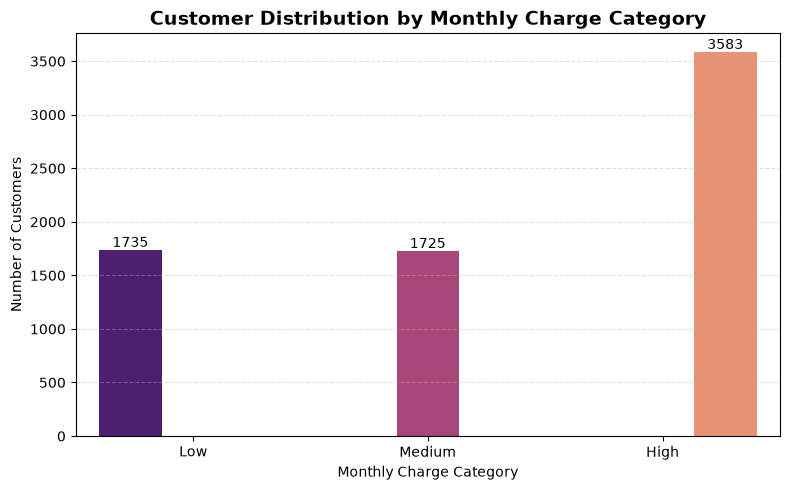

In [10]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='MonthlyCharge_Category',
    data=df,
    hue='MonthlyCharge_Category',
    palette='magma',
    legend=False
)

plt.title('Customer Distribution by Monthly Charge Category',
          fontsize=14,
          fontweight='bold')

plt.xlabel('Monthly Charge Category')
plt.ylabel('Number of Customers')

plt.grid(axis='y', linestyle='--', alpha=0.4)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()



plt.show()



## Conclusion

Successfully created tenure-based and monthly charge-based features. These engineered features will be used in subsequent predictive modeling tasks such as Logistic Regression, Random Forest, and XGBoost.

# Week 2 - Commit 2

# Advanced Feature Engineering

## Objective

To create advanced customer behavior features such as Customer Engagement Level, Total Services, and Internet Service indicators that improve churn prediction and customer segmentation.


In [11]:
service_columns = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['TotalServices'] = (
    df[service_columns]
    .replace({'Yes':1, 'No':0, 'No internet service':0, 'No phone service':0})
    .sum(axis=1)
)

print("TotalServices feature created")

TotalServices feature created


In [12]:
df['InternetServiceFlag'] = df['InternetService'].apply(
    lambda x: 0 if x == 'No' else 1
)

print("InternetServiceFlag created")

InternetServiceFlag created


In [13]:
df['SecuritySupport'] = (
    (df['OnlineSecurity'] == 'Yes') &
    (df['TechSupport'] == 'Yes')
).astype(int)

print("SecuritySupport feature created")

SecuritySupport feature created


In [14]:
print(df[['TotalServices',
          'InternetServiceFlag',
          'SecuritySupport']].head())

  TotalServices  InternetServiceFlag  SecuritySupport
0             1                    1                0
1             3                    1                0
2             3                    1                0
3             3                    1                1
4             1                    1                0


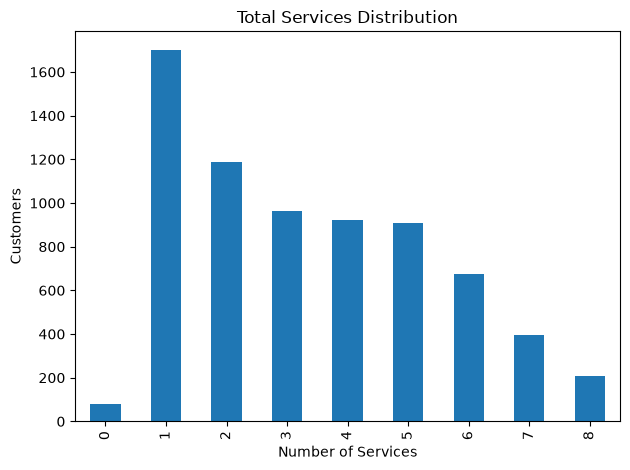

In [15]:
import matplotlib.pyplot as plt

df['TotalServices'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title("Total Services Distribution")
plt.xlabel("Number of Services")
plt.ylabel("Customers")
plt.tight_layout()

plt.savefig("../screenshots/week2_commit2_total_services_distribution.png")
plt.show()

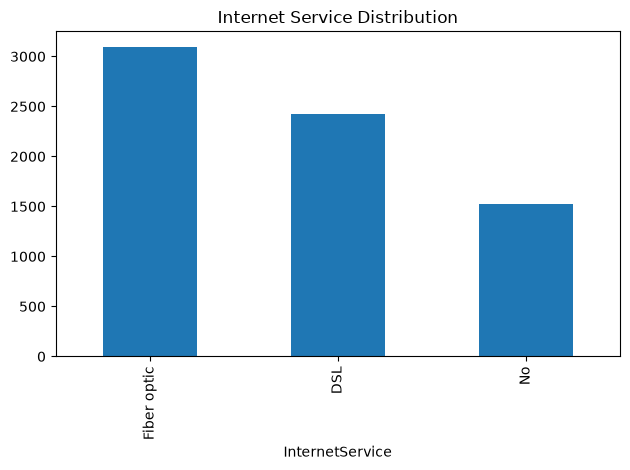

In [16]:
df['InternetService'].value_counts().plot(
    kind='bar'
)

plt.title("Internet Service Distribution")
plt.tight_layout()

plt.savefig("../screenshots/week2_commit2_internet_service_distribution.png")
plt.show()

In [18]:
df['PremiumCustomerScore'] = (
    (df['MonthlyCharges'] > df['MonthlyCharges'].median()) &
    (df['TotalServices'] >= 4)
).astype(int)

print("PremiumCustomerScore created")

PremiumCustomerScore created


In [20]:
df['SecurityAwarenessScore'] = (
    (df['OnlineSecurity'] == 'Yes').astype(int) +
    (df['OnlineBackup'] == 'Yes').astype(int) +
    (df['DeviceProtection'] == 'Yes').astype(int)
)

print("SecurityAwarenessScore created")

SecurityAwarenessScore created


In [21]:
df['EntertainmentScore'] = (
    (df['StreamingTV'] == 'Yes').astype(int) +
    (df['StreamingMovies'] == 'Yes').astype(int)
)

print("EntertainmentScore created")

EntertainmentScore created


In [24]:
service_columns = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df['ServiceAdoptionScore'] = (
    df[service_columns]
    .replace({
        'Yes': 1,
        'No': 0,
        'No internet service': 0,
        'No phone service': 0
    })
    .sum(axis=1)
)

print("ServiceAdoptionScore created")

ServiceAdoptionScore created


In [25]:
def engagement(score):
    if score <= 2:
        return "Low"
    elif score <= 5:
        return "Medium"
    else:
        return "High"

df["CustomerEngagementLevel"] = df["ServiceAdoptionScore"].apply(engagement)

print("CustomerEngagementLevel created")

CustomerEngagementLevel created


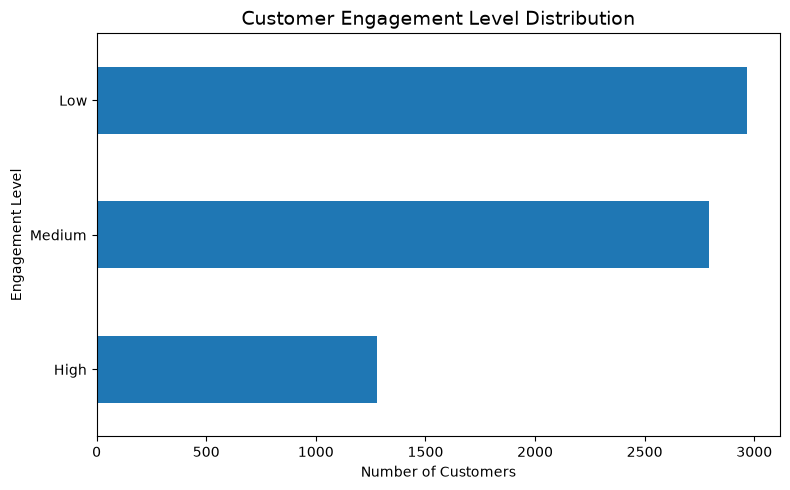

In [28]:
import matplotlib.pyplot as plt

engagement_counts = df['CustomerEngagementLevel'].value_counts()

plt.figure(figsize=(8,5))
engagement_counts.sort_values().plot(kind='barh')

plt.title('Customer Engagement Level Distribution', fontsize=14)
plt.xlabel('Number of Customers')
plt.ylabel('Engagement Level')

plt.tight_layout()
plt.savefig('../screenshots/week2_commit2_customer_engagement_barh.png')
plt.show()

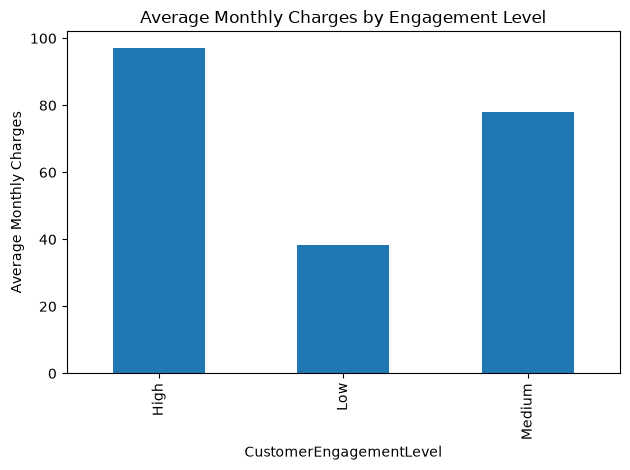

In [29]:
df.groupby('CustomerEngagementLevel')['MonthlyCharges'].mean().plot(
    kind='bar'
)

plt.title("Average Monthly Charges by Engagement Level")
plt.ylabel("Average Monthly Charges")

plt.tight_layout()

plt.savefig("../screenshots/week2_commit2_engagement_vs_charges.png")
plt.show()

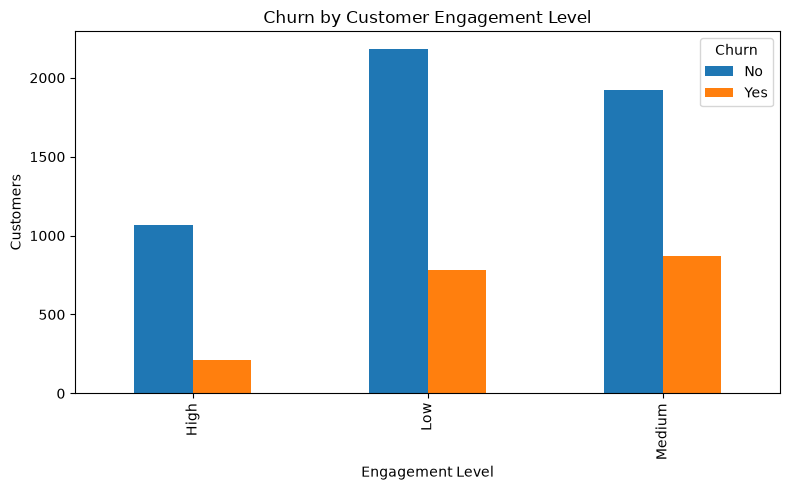

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

pd.crosstab(
    df['CustomerEngagementLevel'],
    df['Churn']
).plot(kind='bar', figsize=(8,5))

plt.title('Churn by Customer Engagement Level')
plt.xlabel('Engagement Level')
plt.ylabel('Customers')

plt.tight_layout()
plt.savefig('../screenshots/week2_commit2_churn_vs_engagement.png')
plt.show()

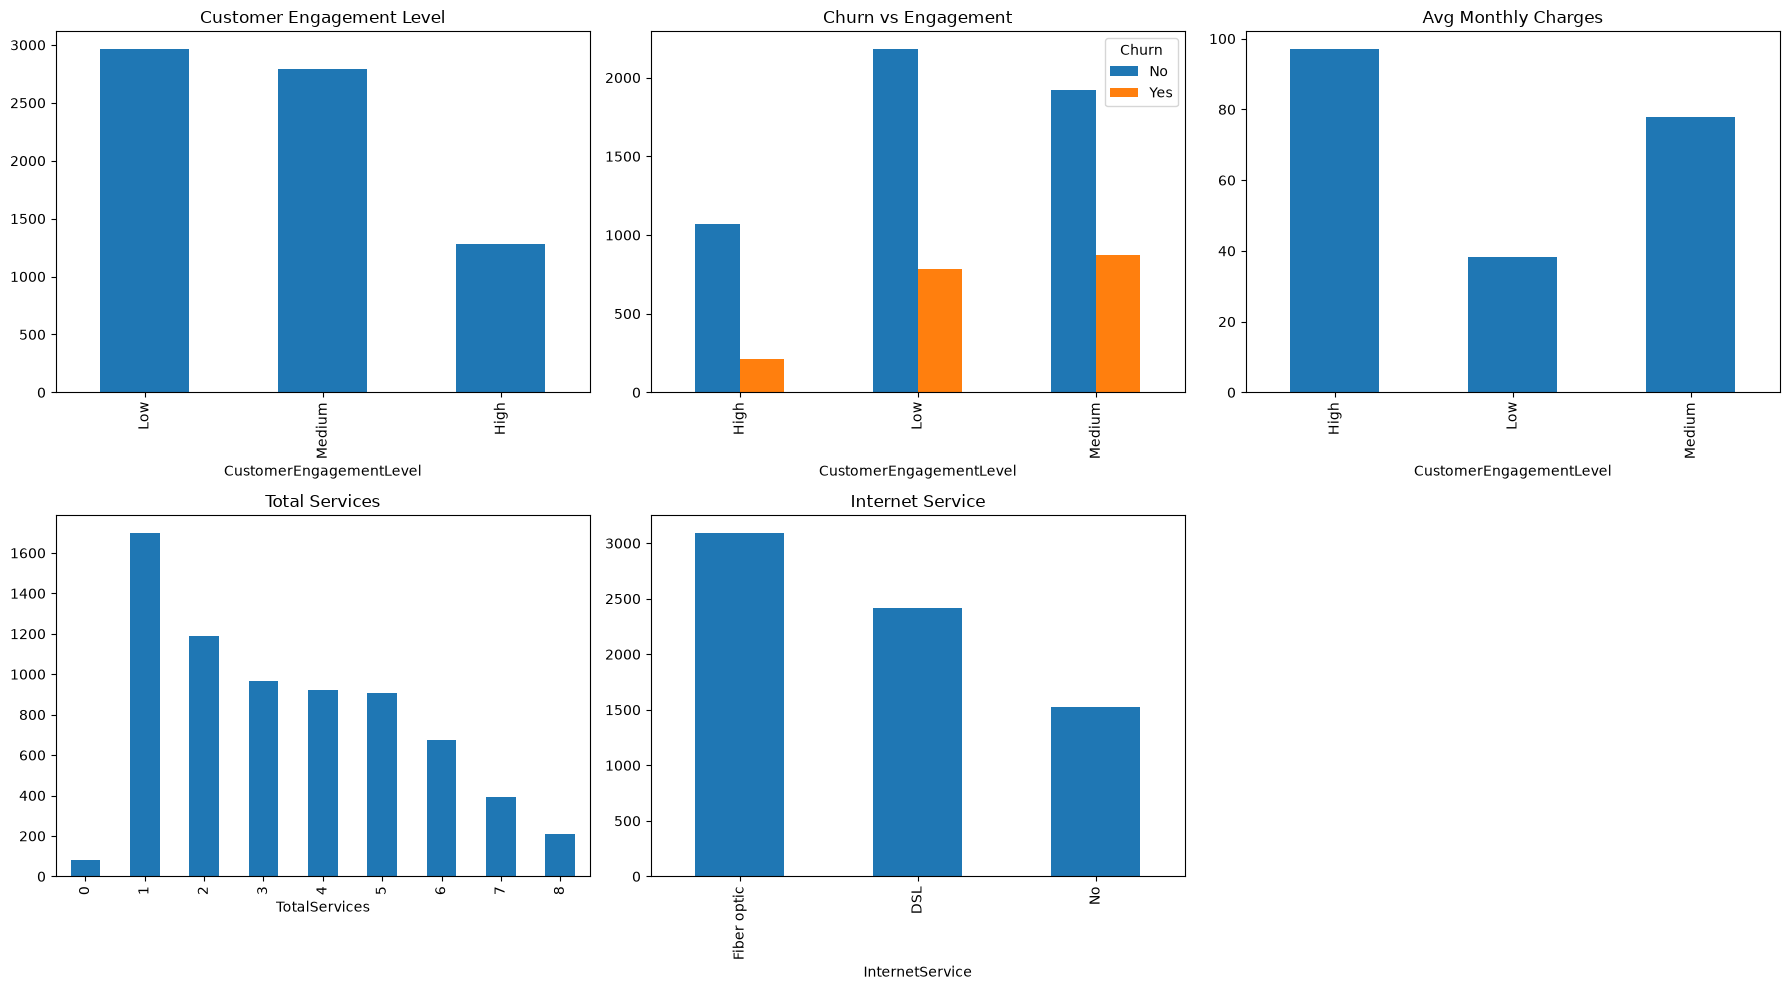

In [31]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(18,10))

# Graph 1
plt.subplot(2,3,1)
df['CustomerEngagementLevel'].value_counts().plot(kind='bar')
plt.title('Customer Engagement Level')

# Graph 2
plt.subplot(2,3,2)
pd.crosstab(
    df['CustomerEngagementLevel'],
    df['Churn']
).plot(kind='bar', ax=plt.gca())
plt.title('Churn vs Engagement')

# Graph 3
plt.subplot(2,3,3)
df.groupby('CustomerEngagementLevel')['MonthlyCharges'].mean().plot(kind='bar')
plt.title('Avg Monthly Charges')

# Graph 4
plt.subplot(2,3,4)
df['TotalServices'].value_counts().sort_index().plot(kind='bar')
plt.title('Total Services')

# Graph 5
plt.subplot(2,3,5)
df['InternetService'].value_counts().plot(kind='bar')
plt.title('Internet Service')

plt.tight_layout()

plt.savefig("../screenshots/week2_commit2_dashboard.png")
plt.show()

In [32]:
df.to_csv(
    "../data/telco_feature_engineered_commit2.csv",
    index=False
)

print("Feature engineered dataset saved successfully")

Feature engineered dataset saved successfully


## Conclusion

Advanced feature engineering was successfully completed by creating meaningful customer behavior features such as Customer Engagement Level and Total Services. These new features provide deeper insights into customer engagement patterns and service usage, helping improve the performance and interpretability of future churn prediction models.